## 1. Load and Explore the Data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)


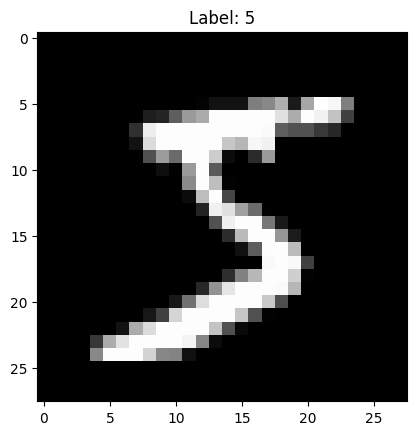

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST, it's built right into keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)

# Look at one example
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

## 2. Preprocess the Data

In [2]:
# Normalize pixel values to 0-1 range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to add the "channel" dimension (28, 28) -> (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New training shape:", x_train.shape)
print("New test shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New test shape: (10000, 28, 28, 1)


## 3. Architecture 1 — Simple Network

In [3]:
model_a = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_a.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model_a.fit(x_train, y_train, epochs=10, validation_split=0.2, batch_size=64)

loss_a, acc_a = model_a.evaluate(x_test, y_test)
print(f"Model A test accuracy: {acc_a:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9061 - loss: 0.3290 - val_accuracy: 0.9589 - val_loss: 0.1371
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9686 - loss: 0.1062 - val_accuracy: 0.9753 - val_loss: 0.0868
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9788 - loss: 0.0729 - val_accuracy: 0.9805 - val_loss: 0.0693
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9827 - loss: 0.0567 - val_accuracy: 0.9807 - val_loss: 0.0682
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9857 - loss: 0.0474 - val_accuracy: 0.9838 - val_loss: 0.0588
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9876 - loss: 0.0396 - val_accuracy: 0.9804 - val_loss: 0.0718
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0335 - val_accuracy: 0.9793 - val_loss: 0.0692
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9910 - loss: 0.0281 - val_accuracy: 0.

## 4. Architecture 2 — Larger Network

In [4]:
model_b = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_b.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model_b.fit(x_train, y_train, epochs=10, validation_split=0.2, batch_size=64)

loss_b, acc_b = model_b.evaluate(x_test, y_test)
print(f"Model B test accuracy: {acc_b:.4f}")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9244 - loss: 0.2434 - val_accuracy: 0.9853 - val_loss: 0.0473
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9789 - loss: 0.0707 - val_accuracy: 0.9850 - val_loss: 0.0527
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9854 - loss: 0.0501 - val_accuracy: 0.9884 - val_loss: 0.0435
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9886 - loss: 0.0382 - val_accuracy: 0.9897 - val_loss: 0.0360
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9914 - loss: 0.0292 - val_accuracy: 0.9880 - val_loss: 0.0444
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9921 - loss: 0.0257 - val_accuracy: 0.9902 - val_loss: 0.0361
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9932 - loss: 0.0219 - val_accuracy: 0.9888 - val_loss: 0.0452
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9948 - loss: 0.0169 - val_accuracy: 0.

## 5. Architecture 3 — Balanced Network

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(x_train, y_train,
                     epochs=10,
                     validation_split=0.2,
                     batch_size=64)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8923 - loss: 0.3469 - val_accuracy: 0.9806 - val_loss: 0.0649
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9711 - loss: 0.1019 - val_accuracy: 0.9843 - val_loss: 0.0582
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9789 - loss: 0.0741 - val_accuracy: 0.9887 - val_loss: 0.0416
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9833 - loss: 0.0569 - val_accuracy: 0.9893 - val_loss: 0.0386
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9861 - loss: 0.0490 - val_accuracy: 0.9902 - val_loss: 0.0364
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9880 - loss: 0.0415 - val_accuracy: 0.9894 - val_loss: 0.0452
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9898 - loss: 0.0349 - val_accuracy: 0.9877 - val_loss: 0.0503
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9911 - loss: 0.0302 - val_accuracy: 0.

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0294
Test accuracy: 0.9925


## 6. Architecture 4 — Pushing for 99.5%

In [8]:
model_d = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_d.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model_d.fit(x_train, y_train, epochs=15, validation_split=0.2, batch_size=64)

loss_d, acc_d = model_d.evaluate(x_test, y_test)
print(f"Model D test accuracy: {acc_d:.4f}")


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9331 - loss: 0.2243 - val_accuracy: 0.9819 - val_loss: 0.0637
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9748 - loss: 0.0855 - val_accuracy: 0.9830 - val_loss: 0.0586
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9817 - loss: 0.0624 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9842 - loss: 0.0554 - val_accuracy: 0.9858 - val_loss: 0.0545
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9853 - loss: 0.0471 - val_accuracy: 0.9890 - val_loss: 0.0428
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9873 - loss: 0.0411 - val_accuracy: 0.9912 - val_loss: 0.0389
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9897 - loss: 0.0350 - val_accuracy: 0.9898 - val_loss: 0.0465
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy: 0

## Comparing All Architectures & Selecting the Final Model


In [9]:
comparison = {
    "Architecture 1 (Simple)": acc_a,
    "Architecture 2 (Larger)": acc_b,
    "Architecture 3 (Balanced)": test_acc,
    "Architecture 4 (Push for 99.5%)": acc_d
}

print(f"{'Architecture':<35} {'Test Accuracy':<15}")
print("-" * 50)
for name, acc in sorted(comparison.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<35} {acc:.4f}")

best_arch = max(comparison, key=comparison.get)
print(f"\nBest performing architecture: {best_arch} ({comparison[best_arch]:.4f})")

Architecture                        Test Accuracy  
--------------------------------------------------
Architecture 3 (Balanced)           0.9925
Architecture 4 (Push for 99.5%)     0.9924
Architecture 2 (Larger)             0.9919
Architecture 1 (Simple)             0.9801

Best performing architecture: Architecture 3 (Balanced) (0.9925)


## 7. Retrain Final Architecture on Full Training Set

In [10]:
# Rebuild the same architecture fresh
final_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

final_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Train on the FULL training set this time, no validation split
final_model.fit(x_train, y_train, epochs=10, batch_size=64)

# Now check against the real test set
final_test_loss, final_test_acc = final_model.evaluate(x_test, y_test)
print(f"Final test accuracy: {final_test_acc:.4f}")

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8951 - loss: 0.3406
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9723 - loss: 0.0988
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9801 - loss: 0.0679
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9847 - loss: 0.0543
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9864 - loss: 0.0474
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9891 - loss: 0.0386
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9911 - loss: 0.0320
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9908 - loss: 0.0307
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9925 - loss: 0.0249
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9928 - loss: 0.0241
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9931 - loss: 0.0274
Final test accuracy: 0.9931


### Analysis of Test Set Performance

The final model achieved a test accuracy of 99.31%, compared to a validation accuracy of 99.08% during architecture selection. These numbers are close together, which suggests the model generalizes well and isn't overfitting to the training data, if anything, training on the full dataset (rather than holding back 20% for validation) gave the model more examples to learn from, which likely explains the slight improvement. This suggests the model would perform reliably on new, unseen handwritten digits similar in style to MNIST.

Note: the 99.08% figure here refers to the validation accuracy from the architecture selection step above, not one of the four architectures' test accuracies in the comparison table.


## 8. Misclassification Analysis

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Number of misclassified images: 69 out of 10000


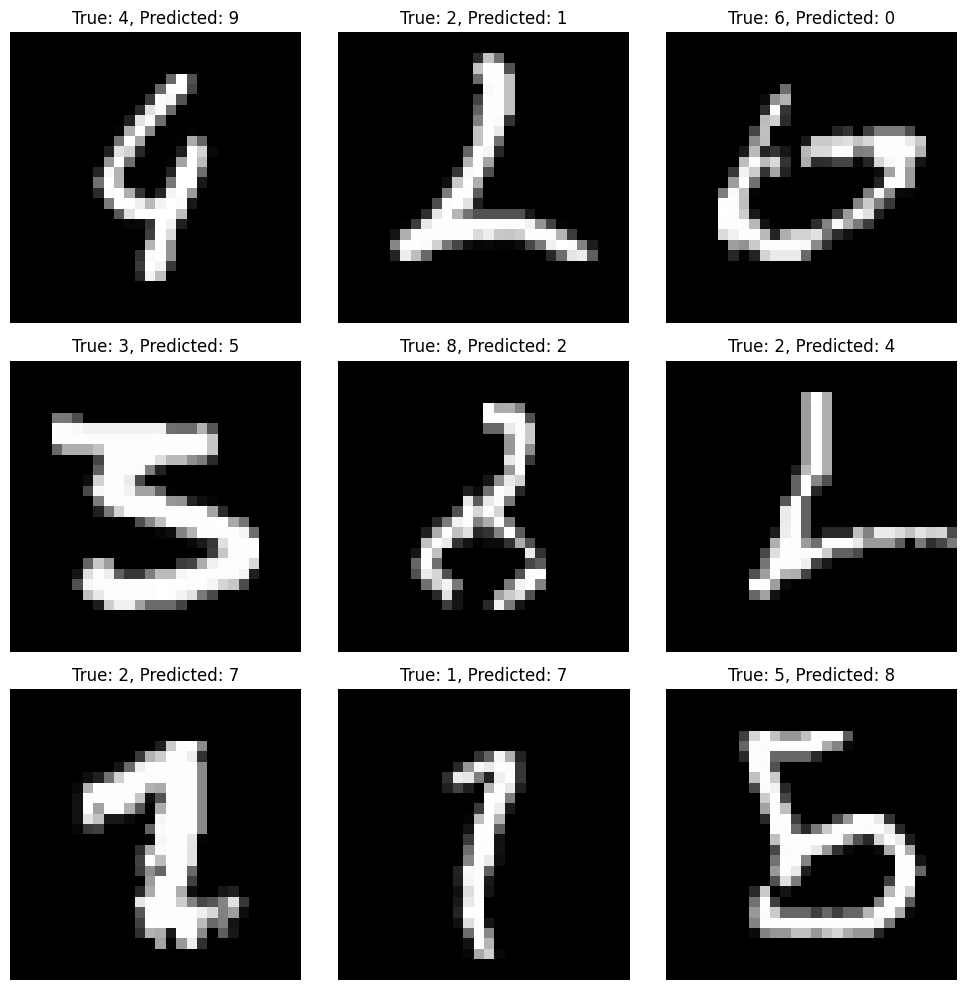

In [11]:
import numpy as np

# Get predictions for the whole test set
predictions = final_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Find where it was wrong
wrong_indices = np.where(predicted_labels != y_test)[0]
print(f"Number of misclassified images: {len(wrong_indices)} out of {len(y_test)}")

# Plot the first 9 mistakes
plt.figure(figsize=(10,10))
for i, idx in enumerate(wrong_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]}, Predicted: {predicted_labels[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Observations on Misclassified Digits

Out of 10,000 test images, the model misclassified only 69 (99.31% accuracy). Looking at the mistakes, a few patterns stand out:

- **Common confusions:** 4→9, 6→0, 3→5, 2→1/4/7, and 1→7 show up repeatedly. These pairs share similar curves or strokes when handwritten quickly or messily (e.g. a 6 with a large loop can resemble a 0, a 2 with a sharp angled top can resemble a 7, and a 1 written with a serif-like flick at the top can resemble a 7).
- **The mistakes aren't random.** They cluster around visually similar digit shapes rather than being spread evenly across all possible confusions, meaning the model is failing on genuinely ambiguous handwriting rather than making arbitrary errors.
- **Some of these are ambiguous even to a human eye.** Several of the misclassified digits, like the 2 predicted as a 1, or the 3 predicted as a 5, are messy enough that a person might reasonably guess the same wrong answer the model did.

**Could the model ever reach 100% accuracy?** Realistically, no. Since some handwritten digits in the dataset are inherently ambiguous or poorly formed, there's a ceiling on achievable accuracy that has less to do with model architecture and more to do with the quality/legibility of the input itself. Even a human classifier would likely make some of the same mistakes on these particular images.



## 9. Export Final Model

In [12]:
final_model.save('mnist_cnn_model.keras')